# Laboratorio 7 — Spark MLlib
## 03. Segmentación de perfiles mediante KMeans

Se busca responder: **¿qué perfiles de trabajadores asalariados pueden identificarse según su edad, antigüedad y jornada habitual?**

- Población: registros de **2025** de `data/processed/personas_2025.parquet` (15 años o más, ocupados, asalariados y con salario positivo registrado).
- El ajuste del escalador, de KMeans y todas las métricas (silhouette, WSSSE, tamaños y perfiles) se calculan con **todos** los registros de 2025 en Spark. A pandas pasan solo tablas agregadas y una muestra de hasta 5,000 registros para dibujar.
- La segmentación es **no ponderada**: describe los registros analizados, no a la población guatemalteca. Una misma persona puede aparecer en más de un trimestre.
- 2026 no se usa en esta sección.

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config, segmentacion

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

config.FIGURES.mkdir(parents=True, exist_ok=True)
config.TABLES.mkdir(parents=True, exist_ok=True)
config.MODELOS.mkdir(parents=True, exist_ok=True)

spark = config.crear_spark("lab7_03_segmentacion")
spark.sparkContext.setLogLevel("ERROR")

pob = segmentacion.agregar_salario_log(
    spark.read.parquet(str(config.DATA_PROCESSED / "personas_2025.parquet"))
).persist()
print("Registros de la población analítica 2025:", f"{pob.count():,}")

26/09/24 16:46:35 WARN Utils: Your hostname, MacBook-Pro-de-Joel-2.local resolves to a loopback address: 127.0.0.1; using 192.168.0.20 instead (on interface en0)
26/09/24 16:46:35 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/24 16:46:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Registros de la población analítica 2025: 53,025


## 1. Selección de variables: ¿vale la pena incluir el salario?

**Variables del perfil:** `edad`, `antiguedad` y `horas_semanales`. Son numéricas continuas, describen la situación laboral de la persona y no dependen del salario.

**Variables que no entran en KMeans:**

- Nivel educativo, categoría ocupacional y dominio son **códigos**, no magnitudes: la distancia euclidiana entre "código 1" y "código 4" no tiene significado, y convertirlas a variables binarias haría que dominaran la distancia. Se usan **después** para describir cada perfil.
- Identificadores, `FACTOR` y `TRIMESTRE` no describen a la persona.

**¿Y el salario?** Se evalúan dos especificaciones con el mismo procedimiento:

| Especificación | Variables |
|---|---|
| `sin_salario` | edad, antigüedad, horas semanales |
| `con_salario` | las tres anteriores + `log10(salario)` |

Cuando se incluye, el salario entra en **log10** solo para la segmentación: tiene una cola derecha muy larga (sección 02) y, en quetzales, unos pocos salarios extremos acapararían un cluster propio. El objetivo del modelado sigue siendo el salario en quetzales.

Hay además un argumento de fondo: el salario es la variable que se intenta **explicar** en la segunda parte. Si define los grupos, los perfiles quedan construidos en parte con la respuesta y ya no sirven para preguntar si perfiles laborales distintos tienen salarios distintos. Por eso la especificación principal es `sin_salario`. La especificación `con_salario` se usa como contraste para ver qué cambia si se incluye.

Todas las variables se **estandarizan** (media 0, desviación 1) con `StandardScaler` dentro del pipeline. Sin estandarizar, las horas (hasta 168) y la edad pesarían más que la antigüedad solo por sus unidades.

In [2]:
resumen_vars = pob.select(*segmentacion.VARIABLES_CON_SALARIO).summary("mean", "stddev", "min", "max").toPandas().set_index("summary").astype(float).T
resumen_vars.index = [segmentacion.ETIQUETAS[v] for v in resumen_vars.index]
resumen_vars

summary,mean,stddev,min,max
Edad (años),35.19,13.52,15.00,89.00
Antigüedad (años),5.56,7.83,0.00,70.00
Horas semanales,46.31,18.63,1.00,126.00
log10(salario),3.42,0.34,0.00,5.00


**Lectura.** Las variables tienen escalas muy distintas: sin estandarizar, la variable con mayor desviación estándar dominaría la distancia euclidiana de KMeans. Después del `StandardScaler` todas quedan con desviación 1 y pesan lo mismo.

## 2. Elección del número de clusters (K = 2, 3, 4 y 5)

Para cada especificación se ajusta el pipeline `VectorAssembler → StandardScaler → KMeans` con semilla fija (`config.SEMILLA`) y se calcula:

- **Silhouette** (distancia euclidiana al cuadrado, `ClusteringEvaluator`): mide qué tan cerca está cada registro de su cluster frente al cluster vecino. Va de −1 a 1; más alto indica grupos más separados.
- **WSSSE** (suma de distancias al cuadrado dentro de los clusters): siempre baja al aumentar K, por lo que se mira dónde deja de bajar mucho (codo).
- **Tamaño del cluster más pequeño** (en % de registros).

**Criterio del grupo: codo del WSSSE, confirmado con silhouette.**

1. Se descartan los K cuyo cluster más pequeño tiene menos del **5 %** de los registros: un grupo así suele reunir valores extremos, no un perfil.
2. Se descarta K = 2: solo parte los registros en dos mitades y no permite distinguir perfiles (el silhouette suele favorecerlo precisamente por eso).
3. Entre los K restantes se elige el **codo**: el K cuya reducción del WSSSE frente a K − 1 es la mayor, es decir, el último cluster que todavía aporta una mejora grande.
4. Se verifica que el silhouette del K elegido indique una estructura razonable (mayor que 0.25) y comparable con los demás K.

In [3]:
resultados, modelos = {}, {}
for nombre, variables in segmentacion.ESPECIFICACIONES.items():
    tabla, mods = segmentacion.evaluar_k(pob, variables, segmentacion.KS)
    tabla.insert(0, "especificacion", nombre)
    resultados[nombre], modelos[nombre] = tabla, mods

metricas_k = pd.concat(resultados.values(), ignore_index=True)
metricas_k.to_csv(config.TABLES / "03_metricas_k.csv", index=False)
metricas_k

,especificacion,k,silhouette,wssse,cluster_menor_pct,cluster_mayor_pct,tamanos,wssse_reduccion_pct
0,sin_salario,2,0.55,"106,717.39",27.54,72.46,"[14604, 38421]",NaN
1,sin_salario,3,0.44,"84,468.15",13.54,55.62,"[16354, 7177, 29494]",20.85
2,sin_salario,4,0.48,"64,438.21",12.95,46.18,"[12742, 8928, 24488, 6867]",23.71
3,sin_salario,5,0.49,"56,848.75",4.93,45.40,"[8541, 2615, 7528, 24071, 10270]",11.78
4,con_salario,2,0.47,"159,174.06",28.15,71.85,"[38097, 14928]",NaN
5,con_salario,3,0.47,"125,145.26",17.71,62.67,"[33229, 10406, 9390]",21.38
6,con_salario,4,0.41,"107,386.66",15.32,51.60,"[8562, 8125, 27359, 8979]",14.19
7,con_salario,5,0.39,"91,789.02",10.66,39.64,"[13019, 5652, 6751, 6585, 21018]",14.52


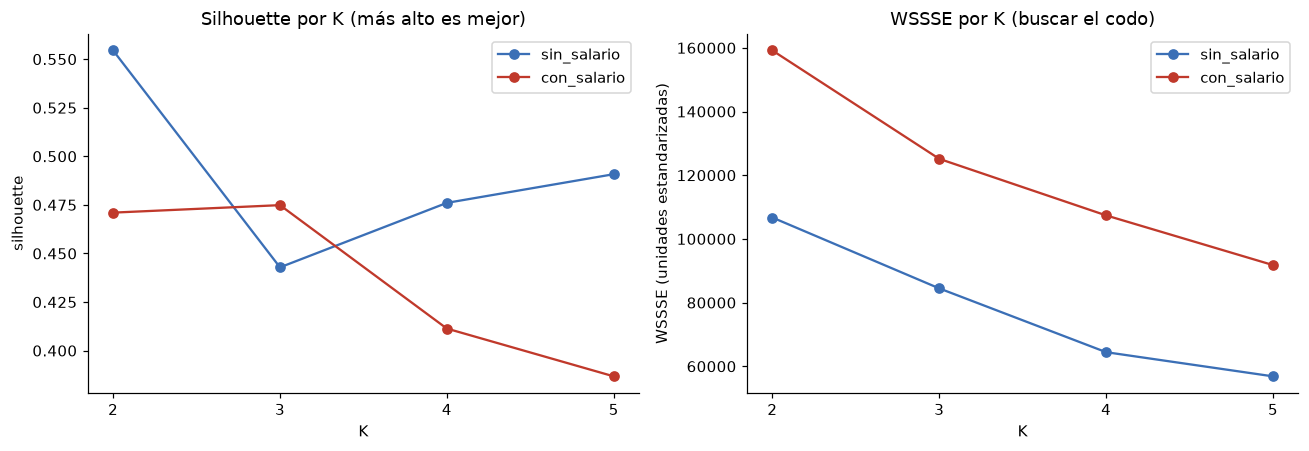

In [4]:
fig, (a, b) = plt.subplots(1, 2, figsize=(12, 4.2))
colores = {"sin_salario": "#3B6FB6", "con_salario": "#C0392B"}
for nombre, t in resultados.items():
    a.plot(t["k"], t["silhouette"], marker="o", color=colores[nombre], label=nombre)
    b.plot(t["k"], t["wssse"], marker="o", color=colores[nombre], label=nombre)
a.set_title("Silhouette por K (más alto es mejor)")
a.set_xlabel("K")
a.set_ylabel("silhouette")
b.set_title("WSSSE por K (buscar el codo)")
b.set_xlabel("K")
b.set_ylabel("WSSSE (unidades estandarizadas)")
for eje in (a, b):
    eje.set_xticks(segmentacion.KS)
    eje.legend()
plt.tight_layout()
plt.savefig(config.FIGURES / "03_eleccion_k.png", dpi=120, bbox_inches="tight")
plt.show()

In [5]:
k_elegido = {nombre: segmentacion.elegir_k(t) for nombre, t in resultados.items()}
for nombre, t in resultados.items():
    fila = t.set_index("k").loc[k_elegido[nombre]]
    mejor_sil = t.loc[t["silhouette"].idxmax()]
    print(f"{nombre}: K elegido = {k_elegido[nombre]} (reducción del WSSSE {fila['wssse_reduccion_pct']:.1f} %, "
          f"silhouette {fila['silhouette']:.3f}, cluster más pequeño {fila['cluster_menor_pct']:.1f} %).")
    print(f"   Mayor silhouette: K = {int(mejor_sil['k'])} ({mejor_sil['silhouette']:.3f}).")
    print("   Reducción del WSSSE al pasar de K-1 a K (%):",
          ", ".join(f"K={int(k)}: {r:.1f}" for k, r in zip(t["k"], t["wssse_reduccion_pct"]) if pd.notna(r)))

K = k_elegido["sin_salario"]
print(f"\nSegmentación principal: sin salario, K = {K}.")

sin_salario: K elegido = 4 (reducción del WSSSE 23.7 %, silhouette 0.476, cluster más pequeño 13.0 %).
   Mayor silhouette: K = 2 (0.554).
   Reducción del WSSSE al pasar de K-1 a K (%): K=3: 20.9, K=4: 23.7, K=5: 11.8
con_salario: K elegido = 3 (reducción del WSSSE 21.4 %, silhouette 0.475, cluster más pequeño 17.7 %).
   Mayor silhouette: K = 3 (0.475).
   Reducción del WSSSE al pasar de K-1 a K (%): K=3: 21.4, K=4: 14.2, K=5: 14.5

Segmentación principal: sin salario, K = 4.


**Interpretación de la elección de K (segmentación sin salario).**

- El mayor silhouette está en **K = 2 (0.55)**, pero esa partición solo separa a las personas mayores con mucha antigüedad (27.5 %) del resto (72.5 %), y la jornada no distingue a los grupos. Es la primera división obvia de los datos, no una segmentación en perfiles.
- El WSSSE baja 20.9 % al pasar de 2 a 3 clusters y **23.7 % de 3 a 4**, pero solo **11.8 % de 4 a 5**: el cuarto cluster todavía aporta una mejora grande y el quinto ya no. El codo está en **K = 4**.
- Con K = 4 el silhouette es **0.48**, prácticamente igual al de K = 5 (0.49) y mayor que el de K = 3 (0.44). K = 5 además genera un cluster con apenas 4.9 % de los registros.
- Un silhouette cercano a 0.5 indica que los perfiles existen pero con fronteras no nítidas: edad, antigüedad y horas son continuas y hay personas en la transición entre un perfil y otro.

## 3. Perfiles de la segmentación principal (sin salario)

Se usa el modelo con el K elegido, ajustado sobre todos los registros de 2025. Los centroides se presentan en unidades estandarizadas (`_z`, desviaciones respecto al promedio) y en unidades originales.

Cada cluster recibe un nombre corto a partir de su centroide estandarizado: un rasgo se menciona cuando el centroide se aleja al menos **media desviación estándar** del promedio (por ejemplo, `edad_z ≥ 0.5` → "mayores"; `horas_semanales_z ≤ −0.5` → "jornada corta").

In [6]:
modelo = modelos["sin_salario"][K]
pred = modelo.transform(pob).persist()

cent = segmentacion.centroides(modelo, segmentacion.VARIABLES_PERFIL)
nombres = segmentacion.nombrar_clusters(cent)
cent.insert(0, "nombre", nombres)
cent.to_csv(config.TABLES / "03_centroides.csv")
cent

,nombre,edad_z,edad,antiguedad_z,antiguedad,horas_semanales_z,horas_semanales
cluster,,,,,,,
0,Mayores,0.99,48.52,-0.19,4.06,-0.37,39.50
1,Jornada larga,-0.34,30.55,-0.26,3.48,1.53,74.76
2,Jóvenes,-0.69,25.82,-0.40,2.42,-0.29,40.95
3,"Mayores, antigüedad alta",1.09,49.90,2.13,22.24,-0.28,41.06


In [7]:
CATEGORIAS = {"1": "Gobierno", "2": "Empresa privada", "3": "Jornalero o peón", "4": "Servicio doméstico"}

perfil = segmentacion.perfil_clusters(pred)
comp = {c: segmentacion.composicion(pred, c) for c in config.CATEGORICAS}
pred_cat = segmentacion.predominante(comp["categoria_ocupacional"])
pred_edu = segmentacion.predominante(comp["nivel_educativo"])
pred_dom = segmentacion.predominante(comp["dominio"])

tabla_perfil = pd.DataFrame({
    "nombre": nombres,
    "registros": perfil["registros"],
    "porcentaje": perfil["porcentaje"],
    "edad_mediana": perfil["edad_mediana"],
    "antiguedad_mediana": perfil["antiguedad_mediana"],
    "horas_mediana": perfil["horas_semanales_mediana"],
    "salario_p25": perfil["salario_mensual_p25"],
    "salario_mediano": perfil["salario_mensual_mediana"],
    "salario_p75": perfil["salario_mensual_p75"],
    "salario_medio": perfil["salario_mensual_media"],
    "categoria_predominante": [f"{CATEGORIAS.get(c, c)} ({p:.0f} %)" for c, p in zip(pred_cat["categoria"], pred_cat["porcentaje"])],
    "educacion_predominante": [f"código {c} ({p:.0f} %)" for c, p in zip(pred_edu["categoria"], pred_edu["porcentaje"])],
    "dominio_predominante": [f"código {c} ({p:.0f} %)" for c, p in zip(pred_dom["categoria"], pred_dom["porcentaje"])],
})
tabla_perfil.to_csv(config.TABLES / "03_perfil_clusters.csv")
tabla_perfil

,nombre,registros,porcentaje,edad_mediana,antiguedad_mediana,horas_mediana,salario_p25,salario_mediano,salario_p75,salario_medio,categoria_predominante,educacion_predominante,dominio_predominante
0,Mayores,12742,24.03,46.00,3.00,42.00,"1,500.00","3,000.00","4,000.00","3,536.70",Empresa privada (46 %),código 2 (36 %),código 1 (47 %)
1,Jornada larga,8928,16.84,29.00,2.00,72.00,"2,000.00","3,000.00","3,900.00","3,240.87",Empresa privada (67 %),código 4 (34 %),código 2 (43 %)
2,Jóvenes,24488,46.18,26.00,1.25,44.00,"1,600.00","3,000.00","3,900.00","3,074.74",Empresa privada (57 %),código 4 (38 %),código 1 (41 %)
3,"Mayores, antigüedad alta",6867,12.95,48.00,20.00,40.00,"2,250.00","3,800.00","6,000.00","4,680.57",Empresa privada (40 %),código 2 (28 %),código 1 (44 %)


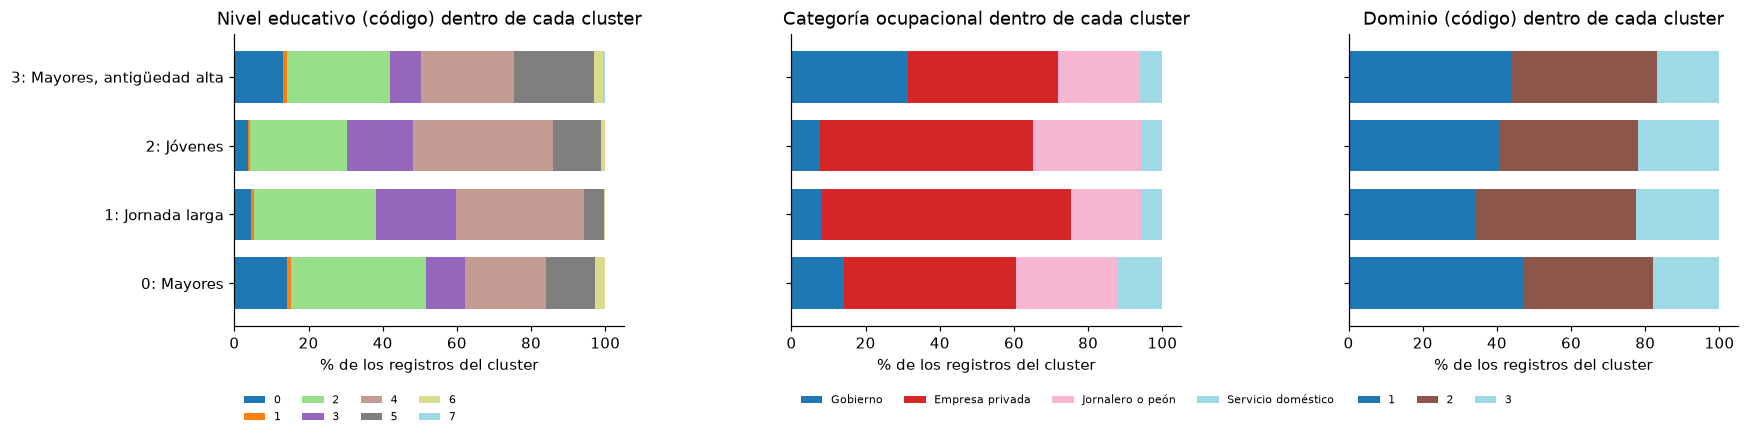

In [8]:
fig, ejes = plt.subplots(1, 3, figsize=(16, 4.2))
titulos = {"categoria_ocupacional": "Categoría ocupacional", "nivel_educativo": "Nivel educativo (código)", "dominio": "Dominio (código)"}
for eje, (col, t) in zip(ejes, comp.items()):
    t = t.rename(columns=CATEGORIAS) if col == "categoria_ocupacional" else t
    t.index = [f"{c}: {nombres[c]}" for c in t.index]
    t.plot.barh(stacked=True, ax=eje, width=.75, colormap="tab20", legend=False)
    eje.set_title(f"{titulos[col]} dentro de cada cluster")
    eje.set_xlabel("% de los registros del cluster")
    eje.legend(fontsize=7, ncol=4, loc="upper left", bbox_to_anchor=(0, -0.2), frameon=False)
for eje in ejes[1:]:
    eje.set_yticklabels([])
plt.tight_layout()
plt.savefig(config.FIGURES / "03_composicion_clusters.png", dpi=120, bbox_inches="tight")
plt.show()

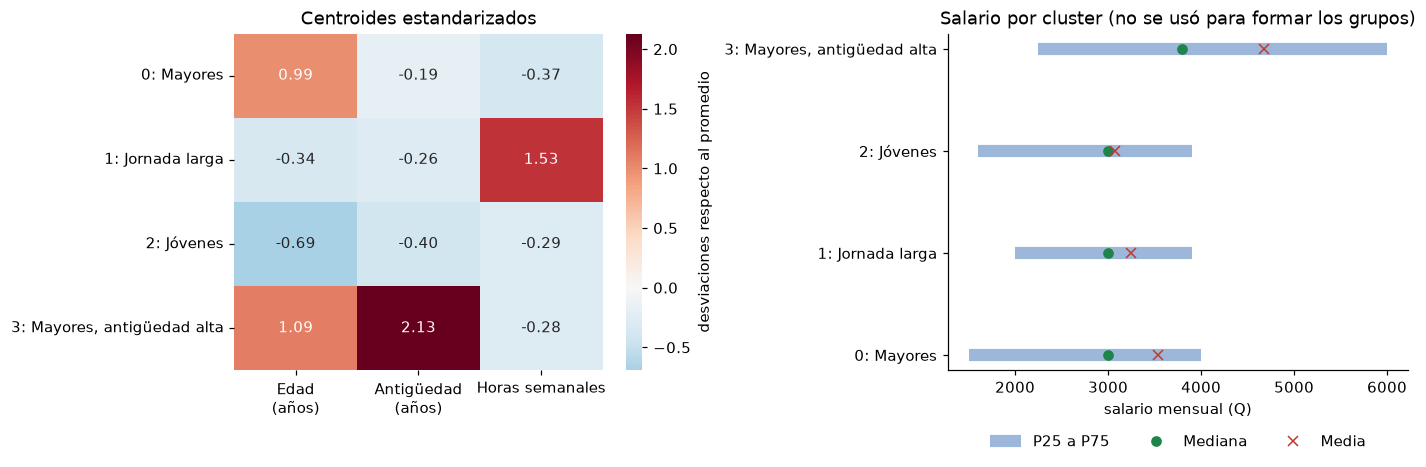

In [9]:
fig, (a, b) = plt.subplots(1, 2, figsize=(13, 4.4))
z = cent[[f"{v}_z" for v in segmentacion.VARIABLES_PERFIL]]
z.columns = [segmentacion.ETIQUETAS[v].replace(" (", "\n(") for v in segmentacion.VARIABLES_PERFIL]
z.index = [f"{c}: {nombres[c]}" for c in z.index]
sns.heatmap(z, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=a, cbar_kws={"label": "desviaciones respecto al promedio"})
a.set_title("Centroides estandarizados")
a.set_ylabel("")
a.tick_params(axis="x", rotation=0)

etiquetas = [f"{c}: {nombres[c]}" for c in tabla_perfil.index]
y = np.arange(len(tabla_perfil))
b.hlines(y, tabla_perfil["salario_p25"], tabla_perfil["salario_p75"], color="#9DB7DB", lw=8, label="P25 a P75")
b.plot(tabla_perfil["salario_mediano"], y, "o", color="#1E8449", label="Mediana")
b.plot(tabla_perfil["salario_medio"], y, "x", color="#C0392B", label="Media")
b.set_yticks(y, etiquetas)
b.set_xlabel("salario mensual (Q)")
b.set_title("Salario por cluster (no se usó para formar los grupos)")
b.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
plt.tight_layout()
plt.savefig(config.FIGURES / "03_centroides_y_salario.png", dpi=120, bbox_inches="tight")
plt.show()

### Visualización con una muestra

La proyección en dos componentes principales (PCA) se ajusta con **todos** los registros sobre las variables estandarizadas; solo se dibuja una muestra aleatoria de hasta 5,000 registros.

Registros dibujados: 5,000. Varianza explicada: PC1 50.5 %, PC2 32.5 % (total 83.0 %).


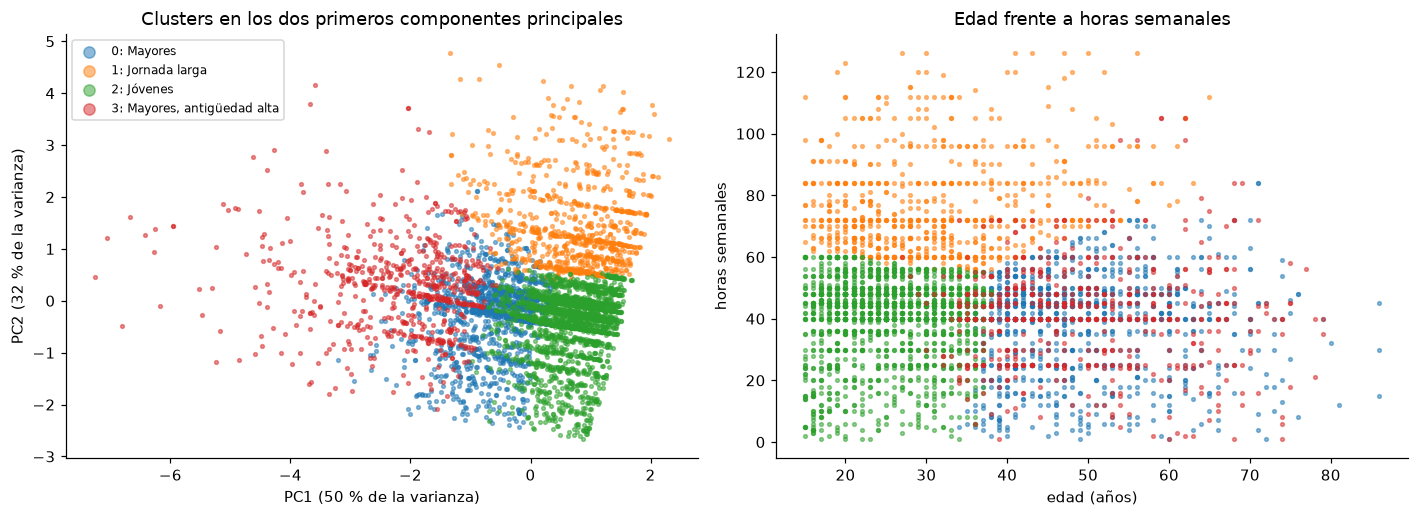

In [10]:
muestra_pca, varianza = segmentacion.proyeccion_pca(pred, n=5000)
print(f"Registros dibujados: {len(muestra_pca):,}. Varianza explicada: PC1 {100 * varianza[0]:.1f} %, PC2 {100 * varianza[1]:.1f} % (total {100 * sum(varianza):.1f} %).")

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 4.8))
paleta = dict(zip(sorted(nombres.index), sns.color_palette("tab10", len(nombres))))
for c, g in muestra_pca.groupby("cluster"):
    a.scatter(g["pc1"], g["pc2"], s=6, alpha=.5, color=paleta[c], label=f"{c}: {nombres[c]}")
    b.scatter(g["edad"], g["horas_semanales"], s=6, alpha=.5, color=paleta[c])
a.set_title("Clusters en los dos primeros componentes principales")
a.set_xlabel(f"PC1 ({100 * varianza[0]:.0f} % de la varianza)")
a.set_ylabel(f"PC2 ({100 * varianza[1]:.0f} % de la varianza)")
a.legend(markerscale=3, fontsize=8)
b.set_title("Edad frente a horas semanales")
b.set_xlabel("edad (años)")
b.set_ylabel("horas semanales")
plt.tight_layout()
plt.savefig(config.FIGURES / "03_clusters_muestra.png", dpi=120, bbox_inches="tight")
plt.show()

### Descripción de cada cluster

La descripción se genera con los valores calculados arriba (medianas, categoría y nivel educativo predominantes, salario mediano).

In [11]:
mediana_global = pred.approxQuantile("salario_mensual", [0.5], 0.0)[0]
for c, f in tabla_perfil.iterrows():
    relacion = f["salario_mediano"] / mediana_global
    print(f"Cluster {c} — {f['nombre']} ({f['registros']:,} registros, {f['porcentaje']:.1f} %)")
    print(f"   Edad mediana {f['edad_mediana']:.0f} años, antigüedad mediana {f['antiguedad_mediana']:.1f} años, "
          f"{f['horas_mediana']:.0f} horas semanales.")
    print(f"   Categoría predominante: {f['categoria_predominante']}; educación predominante: {f['educacion_predominante']}; "
          f"dominio predominante: {f['dominio_predominante']}.")
    print(f"   Salario mediano Q{f['salario_mediano']:,.0f} ({relacion:.2f} veces la mediana general de Q{mediana_global:,.0f}); "
          f"rango intercuartílico Q{f['salario_p25']:,.0f} a Q{f['salario_p75']:,.0f}.\n")

Cluster 0 — Mayores (12,742 registros, 24.0 %)
   Edad mediana 46 años, antigüedad mediana 3.0 años, 42 horas semanales.
   Categoría predominante: Empresa privada (46 %); educación predominante: código 2 (36 %); dominio predominante: código 1 (47 %).
   Salario mediano Q3,000 (1.00 veces la mediana general de Q3,000); rango intercuartílico Q1,500 a Q4,000.

Cluster 1 — Jornada larga (8,928 registros, 16.8 %)
   Edad mediana 29 años, antigüedad mediana 2.0 años, 72 horas semanales.
   Categoría predominante: Empresa privada (67 %); educación predominante: código 4 (34 %); dominio predominante: código 2 (43 %).
   Salario mediano Q3,000 (1.00 veces la mediana general de Q3,000); rango intercuartílico Q2,000 a Q3,900.

Cluster 2 — Jóvenes (24,488 registros, 46.2 %)
   Edad mediana 26 años, antigüedad mediana 1.2 años, 44 horas semanales.
   Categoría predominante: Empresa privada (57 %); educación predominante: código 4 (38 %); dominio predominante: código 1 (41 %).
   Salario mediano Q3

**Interpretación de los perfiles (K = 4).**

| Cluster | Perfil | Registros | Rasgos (medianas) | Salario mediano (P25–P75) | Lo que lo distingue |
|---|---|---|---|---|---|
| 2 | **Jóvenes al inicio de su trayectoria** | 46.2 % | 26 años, 1.2 años de antigüedad, 44 h | Q3,000 (Q1,600–Q3,900) | Es el grupo más grande; 57 % en empresa privada y 29 % jornaleros; el nivel educativo más frecuente es el código 4 (38 %). |
| 1 | **Jornada extendida** | 16.8 % | 29 años, 2 años de antigüedad, **72 h** | Q3,000 (Q2,000–Q3,900) | Trabaja cerca de 30 horas más por semana que los demás con el mismo salario mediano; 67 % en empresa privada. |
| 0 | **Adultos mayores con poca antigüedad** | 24.0 % | 46 años, 3 años de antigüedad, 42 h | Q3,000 (Q1,500–Q4,000) | Llegaron hace poco a su empleo actual; mayor presencia de personas sin educación (código 0, 14 %), jornaleros (27 %) y servicio doméstico (12 %). |
| 3 | **Trayectoria larga y estable** | 13.0 % | 48 años, **20 años de antigüedad**, 40 h | **Q3,800 (Q2,250–Q6,000)** | Único perfil con salario claramente mayor; concentra el empleo de gobierno (31 % frente a 12 % en toda la muestra) y los niveles educativos más altos (código 5, 22 %). |

- Tres de los cuatro perfiles tienen **el mismo salario mediano (Q3,000)**: la edad y la jornada, por sí solas, no se asocian con un salario mediano distinto. Lo que sí acompaña a un salario mayor es la **antigüedad larga**, que a su vez se mezcla con el empleo de gobierno y con más educación.
- El perfil de **jornada extendida** gana lo mismo trabajando 72 horas en lugar de 40–44: su ingreso por hora es menor. Es coherente con la correlación casi nula entre horas y salario (r = 0.08).
- Los grupos se forman **solo** con edad, antigüedad y horas. Que después muestren salarios, categorías o niveles educativos distintos indica que esas características **acompañan** al perfil laboral; no significa que el perfil los cause.
- La antigüedad está limitada por la edad (filtro de la sección 01), por lo que los perfiles de mayor antigüedad son también de mayor edad. Lo que distingue a los perfiles jóvenes entre sí es sobre todo la **jornada**.
- La separación moderada (silhouette) significa que hay personas en la frontera entre dos perfiles. Los nombres describen el **centro** de cada grupo, no a cada una de sus personas.
- Los porcentajes describen los registros analizados de 2025 (sin ponderar). Con `FACTOR` se podría estimar cuántos trabajadores del país hay en cada perfil, pero eso requeriría el análisis ponderado y el diseño muestral completo.

## 4. Contraste: segmentación con salario

Se revisa qué perfiles aparecen si el `log10(salario)` entra en la segmentación, con el K elegido para esa especificación según el mismo criterio.

In [12]:
K_sal = k_elegido["con_salario"]
modelo_sal = modelos["con_salario"][K_sal]
pred_sal = modelo_sal.transform(pob)

cent_sal = segmentacion.centroides(modelo_sal, segmentacion.VARIABLES_CON_SALARIO)
cent_sal.insert(0, "nombre", segmentacion.nombrar_clusters(cent_sal))
cent_sal["salario_centroide_Q"] = 10 ** cent_sal[segmentacion.SALARIO_LOG]
perfil_sal = segmentacion.perfil_clusters(pred_sal)
cent_sal["registros"] = perfil_sal["registros"]
cent_sal["porcentaje"] = perfil_sal["porcentaje"]
cent_sal.to_csv(config.TABLES / "03_centroides_con_salario.csv")
cent_sal[["nombre", "registros", "porcentaje", "edad", "antiguedad", "horas_semanales", "salario_centroide_Q",
          "edad_z", "antiguedad_z", "horas_semanales_z", f"{segmentacion.SALARIO_LOG}_z"]]

,nombre,registros,porcentaje,edad,antiguedad,horas_semanales,salario_centroide_Q,edad_z,antiguedad_z,horas_semanales_z,salario_log10_z
cluster,,,,,,,,,,,
0,Perfil promedio,33229,62.67,30.19,2.66,52.78,"3,184.57",-0.37,-0.37,0.35,0.25
1,"Mayores, antigüedad alta",10406,19.62,51.02,17.25,43.64,"3,878.85",1.17,1.49,-0.14,0.50
2,"Jornada corta, salario bajo",9390,17.71,35.32,2.88,26.34,829.96,0.01,-0.34,-1.07,-1.44


In [13]:
t_sin = resultados["sin_salario"].set_index("k").loc[K]
t_con = resultados["con_salario"].set_index("k").loc[K_sal]
print(f"Sin salario: K = {K}, silhouette {t_sin['silhouette']:.3f}, cluster más pequeño {t_sin['cluster_menor_pct']:.1f} %.")
print(f"Con salario: K = {K_sal}, silhouette {t_con['silhouette']:.3f}, cluster más pequeño {t_con['cluster_menor_pct']:.1f} %.")
z_sal = cent_sal[f"{segmentacion.SALARIO_LOG}_z"]
print(f"Con salario, los centroides del log10(salario) van de {z_sal.min():+.2f} a {z_sal.max():+.2f} desviaciones estándar: "
      f"{'el salario es uno de los ejes principales de la segmentación' if (z_sal.max() - z_sal.min()) >= 1 else 'el salario separa poco a los grupos'}.")

Sin salario: K = 4, silhouette 0.476, cluster más pequeño 13.0 %.
Con salario: K = 3, silhouette 0.475, cluster más pequeño 17.7 %.
Con salario, los centroides del log10(salario) van de -1.44 a +0.50 desviaciones estándar: el salario es uno de los ejes principales de la segmentación.


**¿Vale la pena incluir el salario?**

- Con salario, el codo está en **K = 3** con silhouette **0.47**, similar al de la segmentación sin salario (0.48): incluirlo **no mejora** la separación.
- Lo que cambia es el contenido. Aparece un grupo de **jornada corta y salario bajo** (17.7 %: 25 horas y salario mediano de Q960, con 52 % de jornaleros y 24 % de servicio doméstico), cuyo rasgo principal es el propio salario (−1.44 desviaciones). Los otros dos grupos repiten a los jóvenes y a los de trayectoria larga que ya aparecían sin salario.
- Es decir, con salario la segmentación se ordena en parte por **tramo de ingreso** y no por perfil laboral, y deja de servir para preguntar si perfiles distintos ganan distinto.

La decisión del grupo es mantener la segmentación **sin salario** como principal: responde a la pregunta planteada (perfiles según edad, antigüedad y jornada), deja el salario como variable de **descripción** para comparar perfiles, y evita construir los grupos con la misma variable que se quiere estimar en la segunda parte. La etiqueta de cluster **no** se usa como predictor en los modelos supervisados.

## 5. Modelo guardado

Se guarda el pipeline completo (ensamblador, escalador y KMeans) de la segmentación principal en `results/modelos/` (no se versiona).

In [14]:
ruta_modelo = config.MODELOS / f"kmeans_sin_salario_k{K}"
modelo.write().overwrite().save(str(ruta_modelo))
print("Modelo guardado en", ruta_modelo.relative_to(RAIZ))

Modelo guardado en results/modelos/kmeans_sin_salario_k4


In [15]:
pred.unpersist()
pob.unpersist()
spark.stop()